# Compare the traces

In [2]:
# --- JUPYTER (Python kernel) ---
import os
# (opcional) hilos de Julia — debe ir ANTES de importar juliacall
import numpy as np
from juliacall import Main as jl

import os
import pathlib
import sys

base_path = pathlib.Path().resolve().parents[1]
PROJECT_ROOT = pathlib.Path("../").resolve()
sys.path.insert(0, str(PROJECT_ROOT))
import paths
from math_analysis.potencial import get_expressions

# 1) Activa tu proyecto y carga el módulo una vez
PROJECT_PATH = "./fitting"  # cambia si tu Project.toml está en otra carpeta
SIM_FILE = "SimNLL.jl"

jl.seval(f"""
using Pkg
Pkg.activate(raw"{PROJECT_PATH}")
Pkg.instantiate()
include(raw"{SIM_FILE}")
using .SimNLL
""")

# 2) Define helpers en Julia (solo Julia aquí dentro)
jl.seval(r"""
@inline function phi(x::Float64)
    x <= 0.0 && return 0.0
    x <= 1.0 && return x*x
    return 2.0 * sqrt(x - 0.75)
end

function trace_x12_to_r123(S_t,U_t,N,sL,sC,sR,noise_amp,dt,th1,th2,th3,Z0,Z1,Z2,side)
    x1 = 0.0; x2 = 0.0
    r1s = zeros(N); r2s = zeros(N); r3s = zeros(N)
    srt = sqrt(dt)
    s1_coef = noise_amp * (srt * 0.5)
    s2_coef = noise_amp * (srt / 6.0)
    @inbounds for i in 1:N
        Sval=S_t[i]; Uval=U_t[i]
        IL = side==0 ? Sval+Uval : Uval
        IC = side==1 ? Sval+Uval : Uval
        IR = side==2 ? Sval+Uval : Uval
        z0=Z0[i]; z1=Z1[i]; z2=Z2[i]
        n1=s1_coef*(z0-z1)
        n2=s2_coef*(z0+z1-2*z2)
        f1a,f2a = SimNLL.drift(x1,x2,IL,IC,IR,sL,sC,sR)
        x1p=x1+f1a*dt+n1
        x2p=x2+f2a*dt+n2
        f1b,f2b = SimNLL.drift(x1p,x2p,IL,IC,IR,sL,sC,sR)
        x1 += 0.5*(f1a+f1b)*dt + n1
        x2 += 0.5*(f2a+f2b)*dt + n2
        r1s[i] =  x1 + x2
        r2s[i] = -x1 + x2
        r3s[i] = -2.0*x2
    end
    r1 = r1s[end]; r2 = r2s[end]; r3 = r3s[end]
    dec = (r1>r2 && r1>r3 && r1>th1) ? 0 :
          (r2>r1 && r2>r3 && r2>th2) ? 1 :
          (r3>r1 && r3>r2 && r3>th3) ? 2 : -1
    return r1s, r2s, r3s, dec
end

function trace_pop4_to_r123(S_t,U_t,N,sL,sC,sR,noise_amp,dt,th1,th2,th3,
                            Z0,Z1,Z2,Z3,side, R, RI, I0; τ=0.1,c=1.0,g=1.0, I_I = 0)
    rL=rC=rR=0.0
    rI=0.0
    sL = sL +1.0
    sC = sC +1.0
    sR = sR +1.0
    # noise_amp = 0
    r1s=zeros(N); r2s=zeros(N); r3s=zeros(N)
    @inbounds for i in 1:N
        Sval=S_t[i]; Uval=U_t[i]
        IL = side==0 ? Sval+Uval : Uval 
        IC = side==1 ? Sval+Uval : Uval
        IR = side==2 ? Sval+Uval : Uval
        ξL=noise_amp*Z0[i]*sqrt(dt)
        ξC=noise_amp*Z1[i]*sqrt(dt)
        ξR=noise_amp*Z2[i]*sqrt(dt)
        ξI=noise_amp*Z3[i]*sqrt(dt)
        fL=1/τ*(-(rL + R) + phi(sL*(rL + R) - c*(rI + RI) + IL + I0))
        fC=1/τ*(-(rC + R) + phi(sC*(rC + R) - c*(rI + RI) + IC + I0))
        fR=1/τ*(-(rR + R) + phi(sR*(rR + R) - c*(rI + RI) + IR + I0))
        fI=1/τ*(-(rI + RI) + phi((g/3)*(rL+rC+rR) + 3*R + I_I))
        rL = rL + fL*dt + ξL 
        rC = rC + fC*dt + ξC
        rR = rR + fR*dt + ξR
        rI = rI + fI*dt + ξI
        r1s[i]=rL; r2s[i]=rC; r3s[i]=rR;
    end
    r1=r1s[end]; r2=r2s[end]; r3=r3s[end]
    dec=(r1>r2 && r1>r3 && r1>th1) ? 0 :
         (r2>r1 && r2>r3 && r2>th2) ? 1 :
         (r3>r1 && r3>r2 && r3>th3) ? 2 : -1
    return r1s, r2s, r3s, dec
end
""")

# 3) Construye el trial y comparte ruido Z0–Z2
# theta =       [sL   , sC   , sR   ,noise_amp, S_amp,    dS , U_amp, U_base,   U_on, U_ext_amp]
import pandas as pd
import sympy as sp
params = pd.read_csv(f'{paths.PARAMS_DIR}/params_df.csv', index_col=0)
X1, X2, I_L, I_C, I_R = sp.symbols('X1 X2 I_L I_C I_R')
values = {
    "tau": 0.1,
    "c": 1,
    "g": 1,
    "s0": 1,
    "IL": 1,
    "IC": 1,
    "IR": 1,
    "I_I": 1/3,
    "sL": params.loc['A92_julia_ext_julia', 'sL'],
    "sC": params.loc['A92_julia_ext_julia', 'sC'],
    "sR": params.loc['A92_julia_ext_julia', 'sR'],
}
# If you want to substitute I_L, I_C, I_R, set substituted_I = True 
# type = symbolic to get the symbolic expressions
_,_,_,_, R, R_I, I_0 = get_expressions(values, type = "symbolic", substituted_I =  False,return_R=True)

theta = params.loc['A92_julia_ext_julia'].to_numpy()

# theta= np.array([0.5026211397513407, 0.4430910004346629, 0.5104974579443251, 1.3430301096795614, 0.20443492617194353, 0.8995819391766191, 1.5288295280633974, -1.0607186107370126, 0.32024637011633444])
# theta = np.array([0.4708087854228893, 0.515426180853467, 0.554879834670885, 0.837818506280247, 0.14053042084733536, 0.309033338612619, 1.8359046443870284, -1.201377929755722, 0.05316830659661856])


Detected IPython. Loading juliacall extension. See https://juliapy.github.io/PythonCall.jl/stable/compat/#IPython


  Activating project at `~/Documents/Mates/Mates4/TFG/simulations/code/fitting/fitting`


Piecewise((0, x < 0), (x**2, x <= 1), (2*sqrt(x - 3/4), True))
R: 0.25 R_I: 0.34027777777777735 I0: 0.5902777777777773


<lambdifygenerated-1>:2: RuntimeWarning: invalid value encountered in sqrt
  return (select([less(I0 + R - R_I, 0),less_equal(I0 + R - R_I, 1),True], [0,2*I0 + 2*R - 2*R_I,2/sqrt(4*I0 + 4*R - 4*R_I - 3)], default=nan) - 1, R - select([less(I0 + R - R_I, 0),less_equal(I0 + R - R_I, 1),True], [0,(I0 + R - R_I)**2,sqrt(4*I0 + 4*R - 4*R_I - 3)], default=nan), R_I - select([less(R + 0.333333333333333, 0),less_equal(R + 0.333333333333333, 1),True], [0,(R + 0.333333333333333)**2,sqrt(4*R - 1.66666666666667)], default=nan),)


Threads: 1
Decisión x1x2 = 1   |   pop4 = 1


/var/folders/gk/r166p6nx2bb5zf2rlwww8fc00000gn/T/ipykernel_27216/995705211.py:47: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  colors = cm.get_cmap('Set1').colors  # devuelve tupla de 9 colores


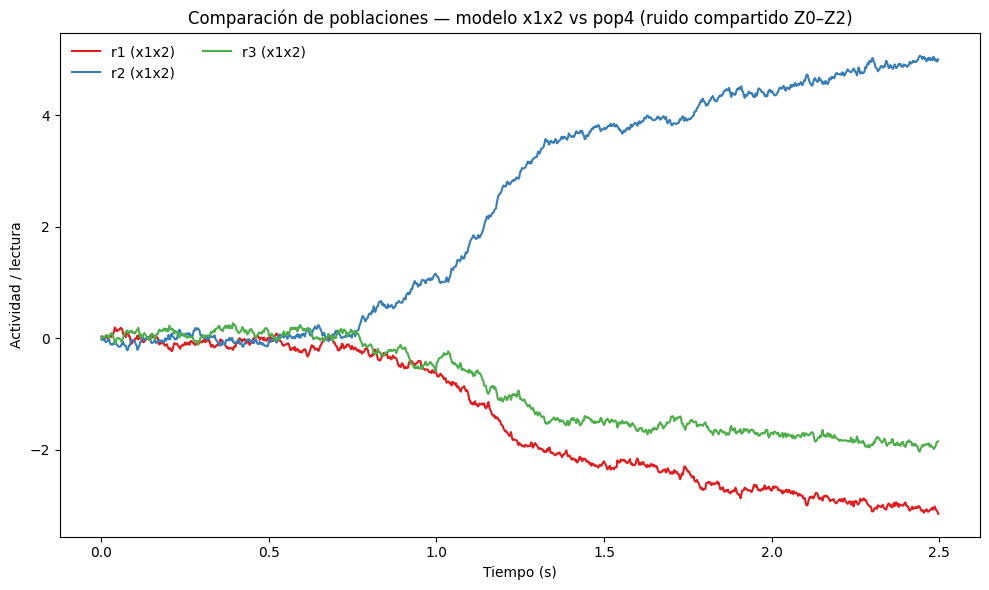

In [3]:

dt, tmax = 0.0025, 2.5
N = int(tmax/dt)
stim, delay, side = 2, 0, 0
t1,t2,t3,t4 = 0.6, 1.3, 1.9, tmax
th1 = th2 = th3 = 0.5

jl_s = jl.zeros(jl.Float64, N)   # Vector{Float64} de longitud N, inicializado a 0.0
jl_u = jl.zeros(jl.Float64, N)

jl.seval(r"""
onset_offset_from_codes_py(stim, delay, t1,t2,t3,t4) =
    SimNLL.onset_offset_from_codes(Int8(stim), Int8(delay), t1, t2, t3, t4)
""")

onset, offset = jl.onset_offset_from_codes_py(jl.Int8(stim), jl.Int8(delay), t1, t2, t3, t4)

S = np.empty(N, dtype=float)
U = np.empty(N, dtype=float)
for k in range(N):
    tt = k*dt
    S[k] = jl.SimNLL.S_value(tt, theta[4], theta[5], onset, offset)   # θ[5],θ[6] en Julia → theta[4],theta[5] en Py
    U[k] = jl.SimNLL.U_value(tt, theta[6], theta[7], theta[8], t4)

jl_s[:] = S
jl_u[:] = U
jl_s = jl.Vector(S)
jl_u = jl.Vector(U)

rng = np.random.default_rng()
Z0 = rng.standard_normal(N); Z1 = rng.standard_normal(N); Z2 = rng.standard_normal(N)
Z3 = rng.standard_normal(N)  # sin ruido en I (cámbialo por standard_normal si quieres)

# 4) Ejecuta y pinta en Python
x1 = jl.seval("trace_x12_to_r123")
p4 = jl.seval("trace_pop4_to_r123")

r1_x12, r2_x12, r3_x12, dec12 = x1(jl_s, jl_u, N, theta[0], theta[1], theta[2], theta[3],
                                   dt, th1, th2, th3, Z0, Z1, Z2, side)
r1_p4, r2_p4, r3_p4, decp4 = p4(jl_s, jl_u, N, theta[0], theta[1], theta[2], theta[3],
                                dt, th1, th2, th3, Z0, Z1, Z2, Z3, side, R, R_I, I_0)

print("Threads:", jl.seval("Threads.nthreads()"))
print(f"Decisión x1x2 = {dec12}   |   pop4 = {decp4}")

import matplotlib.pyplot as plt
from matplotlib import cm
colors = cm.get_cmap('Set1').colors  # devuelve tupla de 9 colores
c_r1, c_r2, c_r3 = colors[0], colors[1], colors[2]  # rojo, azul, verde

t = np.arange(N) * dt
plt.figure(figsize=(10,6))

# modelo x1x2 → líneas sólidas
plt.plot(t, r1_x12, color=c_r1, label='r1 (x1x2)')
plt.plot(t, r2_x12, color=c_r2, label='r2 (x1x2)')
plt.plot(t, r3_x12, color=c_r3, label='r3 (x1x2)')

# # modelo pop4 → mismas poblaciones, línea discontinua
# plt.plot(t, r1_p4, color=c_r1, linestyle='--', label='r1 (pop4)')
# plt.plot(t, r2_p4, color=c_r2, linestyle='--', label='r2 (pop4)')
# plt.plot(t, r3_p4, color=c_r3, linestyle='--', label='r3 (pop4)')

plt.title("Comparación de poblaciones — modelo x1x2 vs pop4 (ruido compartido Z0–Z2)")
plt.xlabel("Tiempo (s)")
plt.ylabel("Actividad / lectura")
# plt.ylim(-1,2)
plt.legend(ncol=2, frameon=False)
plt.tight_layout()
plt.show()

In [121]:
import numpy as np

# --- helpers ---------------------------------------------------------
def run_once_x12(rng, Z_shape, *, share_Z=None):
    """Una execució del model x1x2. Si share_Z és (Z0,Z1,Z2), els reutilitza."""
    if share_Z is None:
        Z0 = rng.standard_normal(Z_shape); Z1 = rng.standard_normal(Z_shape); Z2 = rng.standard_normal(Z_shape)
    else:
        Z0, Z1, Z2 = share_Z
    r1_x12, r2_x12, r3_x12, dec12 = x1(jl_s, jl_u, N, theta[0], theta[1], theta[2], theta[3],
                                       dt, th1, th2, th3, Z0, Z1, Z2, side)
    return int(dec12)

def run_once_p4(rng, Z_shape, *, share_Z=None):
    """Una execució del model pop4. Si share_Z és (Z0,Z1,Z2), reaprofita i genera Z3 nou."""
    if share_Z is None:
        Z0 = rng.standard_normal(Z_shape); Z1 = rng.standard_normal(Z_shape); Z2 = rng.standard_normal(Z_shape)
    else:
        Z0, Z1, Z2 = share_Z
    Z3 = rng.standard_normal(Z_shape)
    r1_p4, r2_p4, r3_p4, decp4 = p4(jl_s, jl_u, N, theta[0], theta[1], theta[2], theta[3],
                                    dt, th1, th2, th3, Z0, Z1, Z2, Z3, side, R, R_I, I_0)
    return int(decp4)

def proportions(vec, classes=(0,1,2,-1)):
    n = len(vec)
    return {c: (np.sum(np.array(vec)==c)/n) for c in classes}

def l1_distance(p, q, classes=(0,1,2,-1)):
    return sum(abs(p.get(c,0.0)-q.get(c,0.0)) for c in classes)

def rmse_distance(p, q, classes=(0,1,2,-1)):
    import math
    return math.sqrt(sum((p.get(c,0.0)-q.get(c,0.0))**2 for c in classes)/len(classes))

def kl_divergence(p, q, eps=1e-12, classes=(0,1,2,-1)):
    import math
    s = 0.0
    for c in classes:
        pc = max(p.get(c,0.0), eps)
        qc = max(q.get(c,0.0), eps)
        s += pc * math.log(pc/qc)
    return s

# --- experiment ------------------------------------------------------
M = 10000  # ajusta a gust

# 2) Cas APARELLAT (soroll compartit Z0–Z2): compara decisió a decisióerent si vols
rng_pair = np.random.default_rng()

dec_x12_pair = []
dec_p4_pair  = []
for _ in range(M):
    # comparteix Z0–Z2 entre models (Z3 només per pop4)
    Z0 = rng_pair.standard_normal(N)
    Z1 = rng_pair.standard_normal(N)
    Z2 = rng_pair.standard_normal(N)
    share = (Z0, Z1, Z2)
    dec_x12_pair.append(run_once_x12(rng_pair, N, share_Z=share))
    dec_p4_pair.append (run_once_p4 (rng_pair, N, share_Z=share))

p_x12_pair = proportions(dec_x12_pair)
p_p4_pair  = proportions(dec_p4_pair)

# matriu de confusió i taxa de desacord
classes = [0,1,2,-1]
idx = {c:i for i,c in enumerate(classes)}
conf = np.zeros((len(classes), len(classes)), dtype=int)
for a,b in zip(dec_x12_pair, dec_p4_pair):
    conf[idx[a], idx[b]] += 1

disagreement = 1.0 - np.mean(np.array(dec_x12_pair) == np.array(dec_p4_pair))

print("\n=== Proporcions (aparellat, Z0-Z2 compartit) ===")
print("x1x2:", p_x12_pair)
print("pop4:", p_p4_pair)
print("L1 diff:", l1_distance(p_x12_pair, p_p4_pair))
print("RMSE  :", rmse_distance(p_x12_pair, p_p4_pair))
print("KL(x12||p4):", kl_divergence(p_x12_pair, p_p4_pair))
print("KL(p4||x12):", kl_divergence(p_p4_pair, p_x12_pair))

print("\nMatriu de confusió (files=x1x2, cols=pop4, ordre classes", classes, "):")
print(conf)
print("Taxa de desacord (aparellat):", disagreement)


=== Proporcions (aparellat, Z0-Z2 compartit) ===
x1x2: {0: np.float64(0.7474), 1: np.float64(0.123), 2: np.float64(0.1296), -1: np.float64(0.0)}
pop4: {0: np.float64(0.5394), 1: np.float64(0.2111), 2: np.float64(0.2495), -1: np.float64(0.0)}
L1 diff: 0.416
RMSE  : 0.12786870219095836
KL(x12||p4): 0.0924324083335154
KL(p4||x12): 0.10152759644043359

Matriu de confusió (files=x1x2, cols=pop4, ordre classes [0, 1, 2, -1] ):
[[4786 1211 1477    0]
 [ 303  743  184    0]
 [ 305  157  834    0]
 [   0    0    0    0]]
Taxa de desacord (aparellat): 0.3637


In [ ]:
df_all = pd.read_csv(f'{paths.DATA_PATH}/df_filtered.csv', sep=';')
df_all = df_all[df_all['timepoint_4'] <= np.percentile(df_all['timepoint_4'], 95)]
def validate_and_encode(df,
                    stim_col='stimd_c', delay_col='ttype_c',
                    side_col='x_c', resp_col='r_c'):
    stim_map  = {'VG':0,'SS':1,'SM':2,'SL':3,'SIL':4}
    side_map  = {'L':0,'C':1,'R':2,'SIL':3}
    resp_map  = {'L':0,'C':1,'R':2}
    delay_map = {'DS':0,'DM':1,'DL':2}

    for col in (stim_col, delay_col, side_col, resp_col):
        if col in df.columns:
            df[col] = df[col].astype('string').str.strip().str.upper()

    stim_ok, side_ok, resp_ok, delay_ok = set(stim_map), set(side_map), set(resp_map), set(delay_map)

    def report(col, okset):
        vals = set(df[col].dropna().unique())
        extras = sorted(list(vals - okset))
        n_nans = int(df[col].isna().sum())
        print(f"[{col}] únicos={sorted(list(vals))} | inesperados={extras} | NaNs={n_nans}")
        return extras, n_nans

    extra_stim, nstim = report(stim_col, stim_ok)
    extra_side, nside = report(side_col, side_ok)
    extra_resp, nresp = report(resp_col, resp_ok)
    if extra_stim or extra_side or extra_resp or nstim or nside or nresp:
        raise ValueError("Valores inesperados/NaN en stim/side/resp.")

    stim_series  = df[stim_col]
    delay_series = df[delay_col]
    mask_delay_needed = stim_series.isin(['SS','SM'])
    bad_delay = mask_delay_needed & ~delay_series.isin(list(delay_ok))
    if bad_delay.any():
        rows = int(bad_delay.sum())
        ejemplos = delay_series[bad_delay].value_counts().to_dict()
        raise ValueError(f"ttype_c inválido cuando stim es SS/SM ({rows} filas): {ejemplos}")

    stimd = stim_series.map(stim_map).astype('Int64')
    side  = df[side_col].map(side_map).astype('Int64')
    resp  = df[resp_col].map(resp_map).astype('Int64')

    delayd = np.empty(len(df), dtype=np.int64)
    delayd[:] = 0
    idx_need = mask_delay_needed.values
    delayd[idx_need] = delay_series[idx_need].map(delay_map).astype('Int64').to_numpy(dtype=np.int64)

    for name, s in [('stimd', stimd), ('side', side), ('resp', resp)]:
        if int(s.isna().sum()):
            raise ValueError(f"Mapeo produjo NaN en {name}.")
    tp_cols = ['timepoint_1','timepoint_2','timepoint_3','timepoint_4']
    if df[tp_cols].isna().any().any():
        raise ValueError("NaNs en timepoints.")
    if (df['timepoint_4'] <= 0).any():
        raise ValueError("Hay trials con timepoint_4 <= 0.")

    stimd  = stimd.to_numpy(dtype=np.int8)
    side   = side.to_numpy(dtype=np.int8)
    resp   = resp.to_numpy(dtype=np.int8)
    delayd = delayd.astype(np.int8)

    t1 = df['timepoint_1'].to_numpy(dtype=np.float64)
    t2 = df['timepoint_2'].to_numpy(dtype=np.float64)
    t3 = df['timepoint_3'].to_numpy(dtype=np.float64)
    t4 = df['timepoint_4'].to_numpy(dtype=np.float64)

return stimd, delayd, side, resp, t1, t2, t3, t4, df


df = df_all[(df_all['subject'] == subject) & (df_all['timepoint_4'] <= np.percentile(df_all['timepoint_4'], 95))].copy()
df = df[df['ttype_c']!='SIL']